<a href="https://colab.research.google.com/github/jaiswalsourav/ML-Model-/blob/main/first_mlproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **My first ML project**


## **Load Data**

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv')
df

## **Data Sepreration**

###  **Data Seperation as x and y**

In [ ]:
y = df['logS']
y

In [ ]:
x = df.drop('logS', axis=1)
x

### Data Split

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

In [ ]:
x_train

In [ ]:
x_test

## **Training Model**

### **Linear Regression**

Training Model

In [13]:
from sklearn.linear_model import LinearRegression

lr =LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

Predection model

In [14]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

In [ ]:
y_lr_train_pred

In [ ]:
y_lr_test_pred

### **Evaluate Model Proformance**

In [17]:
from sklearn.metrics import mean_squared_error, r2_score
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [18]:
print('LR MSE (Train): ', lr_train_mse)
print('LR R2 (Train): ', lr_train_r2)
print('LR MSE (Test): ', lr_test_mse)
print('LR R2 (Test): ', lr_test_r2)


LR MSE (Train):  1.0075362951093687
LR R2 (Train):  0.7645051774663391
LR MSE (Test):  1.0206953660861033
LR R2 (Test):  0.7891616188563282


In [ ]:
lr_Result=pd.DataFrame(['Linear Regression',lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_Result.columns=['Model','Training MSE','Training R2','Test MSE','Test R2']
lr_Result

## **Random Forest**

### **Linear Regression**

Training Model

In [25]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=2, random_state=100)

Predection model

In [29]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

### **Evaluate Model Proformance**

In [30]:
from sklearn.metrics import mean_squared_error, r2_score
rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [31]:
print('LR MSE (Train): ', rf_train_mse)
print('LR R2 (Train): ', rf_train_r2)
print('LR MSE (Test): ', rf_test_mse)
print('LR R2 (Test): ', rf_test_r2)

LR MSE (Train):  1.028227802112806
LR R2 (Train):  0.7596688824431413
LR MSE (Test):  1.407688264904896
LR R2 (Test):  0.7092230211002489


In [32]:
lr_Result=pd.DataFrame(['Linear Regression',rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
lr_Result.columns=['Model','Training MSE','Training R2','Test MSE','Test R2']
lr_Result

,Model,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,1.028228,0.759669,1.407688,0.709223


## **Model Comparision**

In [36]:
df_models =pd.concat([lr_Result,lr_Result],axis=0)
df_models.reset_index(drop=True)



,Model,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,1.028228,0.759669,1.407688,0.709223
1,Linear Regression,1.028228,0.759669,1.407688,0.709223


## **Visualization of predicted Model**

Text(0.5, 1.0, 'Linear Regression Model Performance')

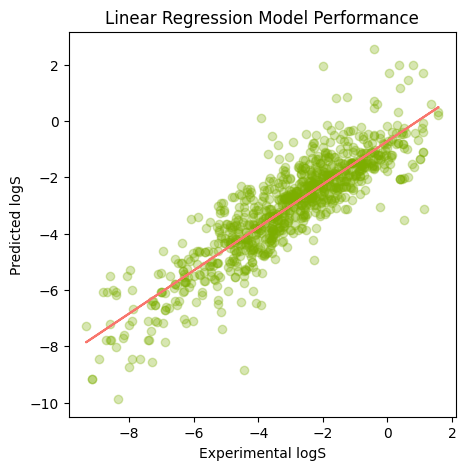

In [43]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,5))
plt.scatter(y_train, y_lr_train_pred, c="#7CAE00", alpha=0.3)

z=np.polyfit(y_train, y_lr_train_pred, 1)
p=np.poly1d(z)

plt.plot(y_train, p(y_train), '#F8766D')
plt.xlabel("Experimental logS")
plt.ylabel("Predicted logS")
plt.title("Linear Regression Model Performance")